In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
from scipy.stats import pearsonr

In [114]:
def plot_expected_transfer(district, tol, numfeatures):
    # List of CSV files for each method

    if district == "all":
        csv_files = {
            #'saturation': 'results/{}_equity_saturation_uncondtol={}.csv'.format(district, tol),
            #'binary': 'results/{}_equity_binary_uncondtol={}.csv'.format(district, tol),
            #'geographic': 'results/{}_equity_geographic_uncondtol={}.csv'.format(district,tol),
            'Poverty Gap Targeting': 'results/{}_equity_conditional_optimized_uncondtol={}_numfeatures={}.csv'.format(district, tol, numfeatures),
            'Poverty Rate Targeting': 'results/{}_equity_optimized_uncondtol={}_numfeatures={}.csv'.format(district, tol, numfeatures),
            #'Oracle Poverty Rate Targeting': 'results/{}_equity_oracle_uncondtol={}.csv'.format(district,tol),
        }
        colors = ['blue', 'orange', 'green']
        fig, axs = plt.subplots(2, len(csv_files), figsize=(5*len(csv_files), 10))
    else:
        csv_files = {
            'saturation': 'results/{}_equity_saturation_uncondtol={}.csv'.format(district, tol),
            'binary': 'results/{}_equity_binary_uncondtol={}.csv'.format(district, tol),
            'optimized': 'results/{}_equity_optimized_uncondtol={}.csv'.format(district, tol),
        }
        colors = cycle(['blue', 'orange', 'red'])
        fig, axs = plt.subplots(1, len(csv_files), figsize=(5*len(csv_files), 5), sharex=True, sharey=True)

    for i, (method, csv_file) in enumerate(csv_files.items()):
        # Load data for the current method
        data = pd.read_csv(csv_file)

        # Plot consumption vs. average transfer value in the current subplot
        if district == "all":
            alpha = 0.10
        else:
            alpha = 0.3
        axs[0, i].scatter(np.log(data['consumption']), data['ev_transfer'], alpha=alpha, color=colors[i])
        axs[0, i].set_title(f'{method}', fontsize=15)
        axs[0, i].set_xlabel('Log Consumption ' + r"$(\log Y)$", fontsize=15)
        axs[0, i].set_ylabel('Expected Transfer (2017 USD PPP) ', fontsize=15)
        axs[0, i].axvline(x=np.log(2.15), label="Poverty Line", color="black")
        axs[0, i].grid(True)
        axs[1, i].hist(data['ev_transfer'], density=True, color=colors[i])
        axs[0, i].set_ylim(-0.05, 2.)
        axs[1, i].set_ylim(0, 5.)
        axs[1, i].set_title(f' Histogram of Transfers', fontsize=15)
        axs[1, i].set_ylabel("Density", fontsize=15)
        axs[1, i].set_xlabel("Transfer Amount", fontsize=15)
        axs[0, i].legend(fontsize=15)

    plt.suptitle("Malawi:  Expected Transfer vs. Log Consumption \n Post-Transfer Poverty Rate={}".format(tol), fontsize=20)
    plt.tight_layout()
    plt.savefig("figs/{}_equity_tol={}.pdf".format(district, tol))
    plt.show()

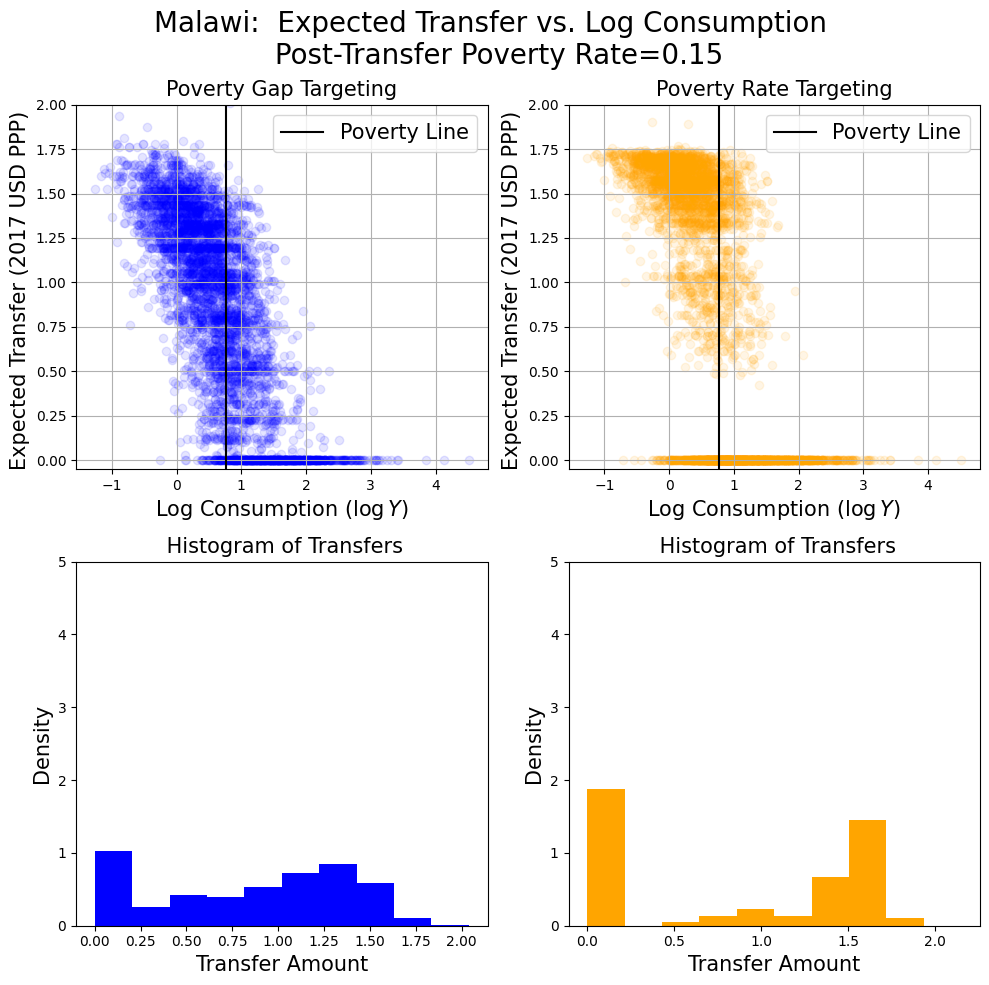

In [119]:
plot_expected_transfer("all", 0.15, 8)